In [ ]:
import pandas as pd
import numpy as np
import os

In [ ]:
columns = (
    ["unit_id", "cycle", "setting1", "setting2", "setting3"]
    + [f"sensor{i}" for i in range(1, 22)]
)

len(columns)

26

In [ ]:
def load_cmapss_dataset(dataset_id, data_path):

    train_path = os.path.join(
        data_path,
        f"train_{dataset_id}.txt"
    )

    test_path = os.path.join(
        data_path,
        f"test_{dataset_id}.txt"
    )

    rul_path = os.path.join(
        data_path,
        f"RUL_{dataset_id}.txt"
    )

    train = pd.read_csv(
        train_path,
        sep=r"\s+",
        header=None,
        names=columns
    )

    test = pd.read_csv(
        test_path,
        sep=r"\s+",
        header=None,
        names=columns
    )

    rul = pd.read_csv(
        rul_path,
        header=None,
        names=["RUL"]
    )

    # Add dataset name
    train["dataset"] = dataset_id
    test["dataset"] = dataset_id

    return train, test, rul

In [ ]:
import zipfile, os;
zip_ref = zipfile.ZipFile("/content/CMAPSSData.zip", "r");
zip_ref.extractall("/content/CMAPSSData");
zip_ref.close();
print(os.listdir("/content/CMAPSSData"))

['train_FD003.txt', 'test_FD002.txt', 'RUL_FD004.txt', 'train_FD004.txt', 'train_FD001.txt', 'RUL_FD003.txt', 'RUL_FD002.txt', 'RUL_FD001.txt', 'test_FD001.txt', 'test_FD003.txt', 'test_FD004.txt', 'train_FD002.txt', 'readme.txt', 'Damage Propagation Modeling.pdf']


In [ ]:
fd001_train, fd001_test, fd001_rul = load_cmapss_dataset(
    "FD001", "/content/CMAPSSData" )

fd002_train, fd002_test, fd002_rul = load_cmapss_dataset(
    "FD002", "/content/CMAPSSData" )

fd003_train, fd003_test, fd003_rul = load_cmapss_dataset(
    "FD003", "/content/CMAPSSData" )

fd004_train, fd004_test, fd004_rul = load_cmapss_dataset(
    "FD004", "/content/CMAPSSData" )

In [ ]:
import os

for root, dirs, files in os.walk("/content"):
    for file in files:
        if "FD001" in file:
            print(os.path.join(root, file))

/content/CMAPSSData/train_FD001.txt
/content/CMAPSSData/RUL_FD001.txt
/content/CMAPSSData/test_FD001.txt


In [ ]:
datasets = {
    "FD001": (fd001_train, fd001_test, fd001_rul),
    "FD002": (fd002_train, fd002_test, fd002_rul),
    "FD003": (fd003_train, fd003_test, fd003_rul),
    "FD004": (fd004_train, fd004_test, fd004_rul)
}

for name, (train, test, rul) in datasets.items():
    print(
        name,
        "| Train:", train.shape,
        "| Test:", test.shape,
        "| RUL:", rul.shape
    )

FD001 | Train: (20631, 27) | Test: (13096, 27) | RUL: (100, 1)
FD002 | Train: (53759, 27) | Test: (33991, 27) | RUL: (259, 1)
FD003 | Train: (24720, 27) | Test: (16596, 27) | RUL: (100, 1)
FD004 | Train: (61249, 27) | Test: (41214, 27) | RUL: (248, 1)


In [ ]:
for dataset_id, (train, test, rul) in datasets.items():
    train["engine_id"] = (
        train["dataset"].astype(str) + "_" + train["unit_id"].astype(str)
    )

    test["engine_id"] = (
        test["dataset"].astype(str) + "_" + test["unit_id"].astype(str)
    )

print("Engine IDs added successfully!")

Engine IDs added successfully!


In [ ]:
for dataset_id, (train, test, rul) in datasets.items():

    train.sort_values(
        ["engine_id", "cycle"],
        inplace=True
    )

    test.sort_values(
        ["engine_id", "cycle"],
        inplace=True
    )

print("Data sorted successfully!")

Data sorted successfully!


In [ ]:
for dataset_id, (train, test, rul) in datasets.items():
    max_cycle = train.groupby("engine_id")["cycle"].transform("max")
    train["RUL"] = max_cycle - train["cycle"]

print("RUL calculated successfully!")

RUL calculated successfully!


In [ ]:
print(fd004_train[[
    "engine_id",
    "cycle",
    "RUL"
]].head(10))

  engine_id  cycle  RUL
0   FD004_1      1  320
1   FD004_1      2  319
2   FD004_1      3  318
3   FD004_1      4  317
4   FD004_1      5  316
5   FD004_1      6  315
6   FD004_1      7  314
7   FD004_1      8  313
8   FD004_1      9  312
9   FD004_1     10  311


In [ ]:
print(
    fd004_train[
        fd004_train["engine_id"] == "FD004_1"
    ][["cycle", "RUL"]].tail()
)

     cycle  RUL
316    317    4
317    318    3
318    319    2
319    320    1
320    321    0


In [ ]:
#11
for name, (train, test, rul) in datasets.items():

    print("=" * 50)
    print(name)

    print("Train shape:", train.shape)
    print("Test shape:", test.shape)
    print("RUL shape:", rul.shape)

    print("Missing values in train:",
          train.isnull().sum().sum())

    print("Duplicate rows in train:",
          train.duplicated().sum())

FD001
Train shape: (20631, 29)
Test shape: (13096, 28)
RUL shape: (100, 1)
Missing values in train: 0
Duplicate rows in train: 0
FD002
Train shape: (53759, 29)
Test shape: (33991, 28)
RUL shape: (259, 1)
Missing values in train: 0
Duplicate rows in train: 0
FD003
Train shape: (24720, 29)
Test shape: (16596, 28)
RUL shape: (100, 1)
Missing values in train: 0
Duplicate rows in train: 0
FD004
Train shape: (61249, 29)
Test shape: (41214, 28)
RUL shape: (248, 1)
Missing values in train: 0
Duplicate rows in train: 0


In [ ]:
for name, (train, test, rul) in datasets.items():

    engine_lengths = train.groupby("engine_id")["cycle"].max()

    print(name)
    print("  Shortest engine life:", engine_lengths.min(), "cycles")
    print("  Longest engine life: ", engine_lengths.max(), "cycles")
    print("  Average engine life: ", round(engine_lengths.mean(), 1), "cycles")
    print()

FD001
  Shortest engine life: 128 cycles
  Longest engine life:  362 cycles
  Average engine life:  206.3 cycles

FD002
  Shortest engine life: 128 cycles
  Longest engine life:  378 cycles
  Average engine life:  206.8 cycles

FD003
  Shortest engine life: 145 cycles
  Longest engine life:  525 cycles
  Average engine life:  247.2 cycles

FD004
  Shortest engine life: 128 cycles
  Longest engine life:  543 cycles
  Average engine life:  246.0 cycles



In [ ]:
#13
sensor_cols = [
    c for c in fd001_train.columns
    if c.startswith("sensor")
]

windows = [5, 20]

def add_features(df, sensor_cols, windows):

    df = df.sort_values(["engine_id", "cycle"]).copy()

    grouped = df.groupby("engine_id")

    for sensor in sensor_cols:

        # Rolling Mean & Std لكل window
        for w in windows:
            df[f"{sensor}_rolling_mean_{w}"] = (
                grouped[sensor]
                .transform(lambda x: x.rolling(window=w, min_periods=1).mean())
            )
            df[f"{sensor}_rolling_std_{w}"] = (
                grouped[sensor]
                .transform(lambda x: x.rolling(window=w, min_periods=1).std())
            )

        # Rate of Change
        df[f"{sensor}_rate_of_change"] = grouped[sensor].diff()

    return df


for name in datasets:
    train, test, rul = datasets[name]

    train_fe = add_features(train, sensor_cols, windows)
    test_fe = add_features(test, sensor_cols, windows)

    datasets[name] = (train_fe, test_fe, rul)

    print(name, "-> Train shape after Feature Engineering:", train_fe.shape)

fd001_train, fd001_test, fd001_rul = datasets["FD001"]
fd002_train, fd002_test, fd002_rul = datasets["FD002"]
fd003_train, fd003_test, fd003_rul = datasets["FD003"]
fd004_train, fd004_test, fd004_rul = datasets["FD004"]

/tmp/ipykernel_3978/3432583156.py:19: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df[f"{sensor}_rolling_mean_{w}"] = (
/tmp/ipykernel_3978/3432583156.py:23: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df[f"{sensor}_rolling_std_{w}"] = (
/tmp/ipykernel_3978/3432583156.py:29: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `new

FD001 -> Train shape after Feature Engineering: (20631, 134)


/tmp/ipykernel_3978/3432583156.py:19: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df[f"{sensor}_rolling_mean_{w}"] = (
/tmp/ipykernel_3978/3432583156.py:23: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df[f"{sensor}_rolling_std_{w}"] = (
/tmp/ipykernel_3978/3432583156.py:29: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `new

FD002 -> Train shape after Feature Engineering: (53759, 134)


/tmp/ipykernel_3978/3432583156.py:19: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df[f"{sensor}_rolling_mean_{w}"] = (
/tmp/ipykernel_3978/3432583156.py:23: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df[f"{sensor}_rolling_std_{w}"] = (
/tmp/ipykernel_3978/3432583156.py:29: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `new

FD003 -> Train shape after Feature Engineering: (24720, 134)


/tmp/ipykernel_3978/3432583156.py:19: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df[f"{sensor}_rolling_mean_{w}"] = (
/tmp/ipykernel_3978/3432583156.py:23: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df[f"{sensor}_rolling_std_{w}"] = (
/tmp/ipykernel_3978/3432583156.py:29: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `new

FD004 -> Train shape after Feature Engineering: (61249, 134)


/tmp/ipykernel_3978/3432583156.py:23: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df[f"{sensor}_rolling_std_{w}"] = (
/tmp/ipykernel_3978/3432583156.py:19: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df[f"{sensor}_rolling_mean_{w}"] = (
/tmp/ipykernel_3978/3432583156.py:23: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `new

In [ ]:
for name, (train, test, rul) in datasets.items():

    rate_of_change_cols = [c for c in train.columns if "rate_of_change" in c]
    rolling_cols = [c for c in train.columns if "rolling" in c]

    print(name)
    print("  NaN in rate_of_change columns:", train[rate_of_change_cols].isnull().sum().sum())
    print("  NaN in rolling columns:", train[rolling_cols].isnull().sum().sum())
    print("  Total NaN in train:", train.isnull().sum().sum())
    print("  Number of unique engines:", train['engine_id'].nunique())
    print()

FD001
  NaN in rate_of_change columns: 2100
  NaN in rolling columns: 4200
  Total NaN in train: 6300
  Number of unique engines: 100

FD002
  NaN in rate_of_change columns: 5460
  NaN in rolling columns: 10920
  Total NaN in train: 16380
  Number of unique engines: 260

FD003
  NaN in rate_of_change columns: 2100
  NaN in rolling columns: 4200
  Total NaN in train: 6300
  Number of unique engines: 100

FD004
  NaN in rate_of_change columns: 5229
  NaN in rolling columns: 10458
  Total NaN in train: 15687
  Number of unique engines: 249



In [ ]:
# Fill NaN values After feature engineering

for name, (train, test, rul) in datasets.items():

    train = train.copy()
    test = test.copy()

    train = train.fillna(0)
    test = test.fillna(0)

    datasets[name] = (
        train,
        test,
        rul
    )

print("NaN values filled successfully.")

NaN values filled successfully.


In [ ]:
# Train / Validation Split by Engine

from sklearn.model_selection import train_test_split

train_val_splits = {}

for name, (train, test, rul) in datasets.items():

    unique_engines = train["engine_id"].unique()

    train_engines, val_engines = train_test_split(
        unique_engines,
        test_size=0.2,
        random_state=42
    )

    train_split = train[
        train["engine_id"].isin(train_engines)
    ].copy()

    val_split = train[
        train["engine_id"].isin(val_engines)
    ].copy()

    train_val_splits[name] = {
        "train": train_split,
        "val": val_split,
        "test": test.copy()
    }

    print(name)
    print("Train:", train_split.shape)
    print("Validation:", val_split.shape)
    print()

FD001
Train: (16592, 134)
Validation: (4039, 134)

FD002
Train: (43250, 134)
Validation: (10509, 134)

FD003
Train: (19743, 134)
Validation: (4977, 134)

FD004
Train: (48279, 134)
Validation: (12970, 134)



In [ ]:
# Prepare Final Test Set

for name, (train, test, rul) in datasets.items():

    test = test.sort_values(
        ["engine_id", "cycle"]
    ).copy()

    # Last observed cycle for each engine
    last_cycles = (
        test.groupby("engine_id")
        .tail(1)
        .copy()
    )

    # Extract unit number from engine_id
    last_cycles["unit_id"] = (
        last_cycles["engine_id"]
        .str.split("_")
        .str[-1]
        .astype(int)
    )

    # Create RUL mapping using unit_id
    rul_mapping = {
        i + 1: value
        for i, value in enumerate(rul["RUL"].values)
    }

    last_cycles["RUL"] = (
        last_cycles["unit_id"]
        .map(rul_mapping)
    )

    # Sort by unit_id
    last_cycles = (
        last_cycles
        .sort_values("unit_id")
        .reset_index(drop=True)
    )

    train_val_splits[name]["test_last"] = last_cycles

    print("=" * 50)
    print(name)
    print(last_cycles[["engine_id", "cycle", "RUL"]].head())
    print("Number of test engines:", len(last_cycles))
    print()

FD001
  engine_id  cycle  RUL
0   FD001_1     31  112
1   FD001_2     49   98
2   FD001_3    126   69
3   FD001_4    106   82
4   FD001_5     98   91
Number of test engines: 100

FD002
  engine_id  cycle  RUL
0   FD002_1    258   18
1   FD002_2     55   79
2   FD002_3    165  106
3   FD002_4     86  110
4   FD002_5    148   15
Number of test engines: 259

FD003
  engine_id  cycle  RUL
0   FD003_1    233   44
1   FD003_2    124   51
2   FD003_3    234   27
3   FD003_4     68  120
4   FD003_5    138  101
Number of test engines: 100

FD004
  engine_id  cycle  RUL
0   FD004_1    230   22
1   FD004_2    153   39
2   FD004_3    141  107
3   FD004_4    208   75
4   FD004_5     51  149
Number of test engines: 248



In [ ]:
# Define Model Features

exclude_cols = [
    "unit_id",
    "cycle",
    "dataset",
    "engine_id",
    "RUL"
]

feature_cols = [
    col
    for col in fd001_train.columns
    if col not in exclude_cols
]

print("Number of features:", len(feature_cols))
print("\nFeatures:")
print(feature_cols)

Number of features: 129

Features:
['setting1', 'setting2', 'setting3', 'sensor1', 'sensor2', 'sensor3', 'sensor4', 'sensor5', 'sensor6', 'sensor7', 'sensor8', 'sensor9', 'sensor10', 'sensor11', 'sensor12', 'sensor13', 'sensor14', 'sensor15', 'sensor16', 'sensor17', 'sensor18', 'sensor19', 'sensor20', 'sensor21', 'sensor1_rolling_mean_5', 'sensor1_rolling_std_5', 'sensor1_rolling_mean_20', 'sensor1_rolling_std_20', 'sensor1_rate_of_change', 'sensor2_rolling_mean_5', 'sensor2_rolling_std_5', 'sensor2_rolling_mean_20', 'sensor2_rolling_std_20', 'sensor2_rate_of_change', 'sensor3_rolling_mean_5', 'sensor3_rolling_std_5', 'sensor3_rolling_mean_20', 'sensor3_rolling_std_20', 'sensor3_rate_of_change', 'sensor4_rolling_mean_5', 'sensor4_rolling_std_5', 'sensor4_rolling_mean_20', 'sensor4_rolling_std_20', 'sensor4_rate_of_change', 'sensor5_rolling_mean_5', 'sensor5_rolling_std_5', 'sensor5_rolling_mean_20', 'sensor5_rolling_std_20', 'sensor5_rate_of_change', 'sensor6_rolling_mean_5', 'sensor6_

In [ ]:
# Find Common Features Across All Datasets

common_features = set(feature_cols)

for name, (train, test, rul) in datasets.items():

    common_features = common_features.intersection(
        set(train.columns)
    )

common_features = sorted(list(common_features))

print("Number of common features:", len(common_features))
print("\nCommon features:")
print(common_features)

Number of common features: 129

Common features:
['sensor1', 'sensor10', 'sensor10_rate_of_change', 'sensor10_rolling_mean_20', 'sensor10_rolling_mean_5', 'sensor10_rolling_std_20', 'sensor10_rolling_std_5', 'sensor11', 'sensor11_rate_of_change', 'sensor11_rolling_mean_20', 'sensor11_rolling_mean_5', 'sensor11_rolling_std_20', 'sensor11_rolling_std_5', 'sensor12', 'sensor12_rate_of_change', 'sensor12_rolling_mean_20', 'sensor12_rolling_mean_5', 'sensor12_rolling_std_20', 'sensor12_rolling_std_5', 'sensor13', 'sensor13_rate_of_change', 'sensor13_rolling_mean_20', 'sensor13_rolling_mean_5', 'sensor13_rolling_std_20', 'sensor13_rolling_std_5', 'sensor14', 'sensor14_rate_of_change', 'sensor14_rolling_mean_20', 'sensor14_rolling_mean_5', 'sensor14_rolling_std_20', 'sensor14_rolling_std_5', 'sensor15', 'sensor15_rate_of_change', 'sensor15_rolling_mean_20', 'sensor15_rolling_mean_5', 'sensor15_rolling_std_20', 'sensor15_rolling_std_5', 'sensor16', 'sensor16_rate_of_change', 'sensor16_rolling_

In [ ]:
# Check Feature Names

bad_features = [
    col for col in common_features
    if "_rate_of_change_rate_of_change" in col
    or "_rolling_mean_" in col and "_rolling_mean_" in col.split("_rolling_mean_", 1)[-1]
]

print("Number of suspicious features:", len(bad_features))

if len(bad_features) > 0:
    print("\nSuspicious features:")
    print(bad_features)
else:
    print("Feature names look correct.")

Number of suspicious features: 0
Feature names look correct.


In [ ]:
# Combine Training Data

train_parts = []

for name, splits in train_val_splits.items():

    train_part = splits["train"].copy()
    train_part["dataset"] = name

    train_parts.append(train_part)

combined_train = pd.concat(
    train_parts,
    axis=0,
    ignore_index=True
)

print("Combined training shape:", combined_train.shape)

print("\nRows per dataset:")
print(combined_train["dataset"].value_counts())

Combined training shape: (127864, 134)

Rows per dataset:
dataset
FD004    48279
FD002    43250
FD003    19743
FD001    16592
Name: count, dtype: int64


In [ ]:
# Check Train / Validation Engine Overlap

train_engine_ids = set(combined_train["engine_id"])

for name in train_val_splits:

    val_engine_ids = set(
        train_val_splits[name]["val"]["engine_id"]
    )

    overlap = train_engine_ids.intersection(
        val_engine_ids
    )

    print(
        name,
        "Train/Validation overlap:",
        len(overlap)
    )

FD001 Train/Validation overlap: 0
FD002 Train/Validation overlap: 0
FD003 Train/Validation overlap: 0
FD004 Train/Validation overlap: 0


In [ ]:
# Prepare X and y

X_train = combined_train[common_features].copy()
y_train = combined_train["RUL"].copy()

print("X_train shape:", X_train.shape)
print("y_train shape:", y_train.shape)

X_train shape: (127864, 129)
y_train shape: (127864,)


In [ ]:
# Prepare Validation Data

validation_data = {}

for name in train_val_splits:

    val = train_val_splits[name]["val"].copy()

    X_val = val[common_features].copy()
    y_val = val["RUL"].copy()

    validation_data[name] = {
        "X": X_val,
        "y": y_val
    }

    print(
        name,
        "Validation shape:",
        X_val.shape
    )

FD001 Validation shape: (4039, 129)
FD002 Validation shape: (10509, 129)
FD003 Validation shape: (4977, 129)
FD004 Validation shape: (12970, 129)


In [ ]:
# Random Forest Regressor

from sklearn.ensemble import RandomForestRegressor

rf_model = RandomForestRegressor(
    n_estimators=100,
    random_state=42,
    n_jobs=-1
)

rf_model.fit(
    X_train,
    y_train
)

print("Random Forest training completed.")

Random Forest training completed.


In [ ]:
# Regression Evaluation Function

from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np

def evaluate_regression(model, X, y):

    predictions = model.predict(X)

    mae = mean_absolute_error(y, predictions)
    rmse = np.sqrt(mean_squared_error(y, predictions))

    return mae, rmse

In [ ]:
# Evaluate Random Forest

rf_results = []

for name in validation_data:

    X_val = validation_data[name]["X"]
    y_val = validation_data[name]["y"]

    mae, rmse = evaluate_regression(
        rf_model,
        X_val,
        y_val
    )

    rf_results.append({
        "Dataset": name,
        "MAE": mae,
        "RMSE": rmse
    })

rf_results_df = pd.DataFrame(rf_results)

print("Random Forest Validation Results:")
display(rf_results_df)

Random Forest Validation Results:


,Dataset,MAE,RMSE
0,FD001,26.937361,35.450176
1,FD002,31.416930,44.533262
2,FD003,35.876486,49.454364
3,FD004,44.308772,63.082569


In [ ]:
# XGBoost Regressor

from xgboost import XGBRegressor

xgb_model = XGBRegressor(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=6,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    n_jobs=-1
)

xgb_model.fit(
    X_train,
    y_train
)

print("XGBoost training completed.")

XGBoost training completed.


In [ ]:
# Evaluate XGBoost

xgb_results = []

for name in validation_data:

    X_val = validation_data[name]["X"]
    y_val = validation_data[name]["y"]

    mae, rmse = evaluate_regression(
        xgb_model,
        X_val,
        y_val
    )

    xgb_results.append({
        "Dataset": name,
        "MAE": mae,
        "RMSE": rmse
    })

xgb_results_df = pd.DataFrame(xgb_results)

print("XGBoost Validation Results:")
display(xgb_results_df)

XGBoost Validation Results:


,Dataset,MAE,RMSE
0,FD001,27.857327,36.000068
1,FD002,30.582085,43.278703
2,FD003,34.553085,47.035182
3,FD004,43.895912,62.245699


In [ ]:
# Prepare Final Test Data

test_data = {}

for name in train_val_splits:

    test = train_val_splits[name]["test_last"].copy()

    X_test = test[common_features].copy()
    y_test = test["RUL"].copy()

    test_data[name] = {
        "X": X_test,
        "y": y_test,
        "engine_id": test["engine_id"].copy(),
        "cycle": test["cycle"].copy()
    }

    print(
        name,
        "Test shape:",
        X_test.shape
    )

FD001 Test shape: (100, 129)
FD002 Test shape: (259, 129)
FD003 Test shape: (100, 129)
FD004 Test shape: (248, 129)


In [ ]:
# Final Test Evaluation - XGBoost

xgb_test_results = []

for name in test_data:

    X_test = test_data[name]["X"]
    y_test = test_data[name]["y"]

    mae, rmse = evaluate_regression(
        xgb_model,
        X_test,
        y_test
    )

    xgb_test_results.append({
        "Dataset": name,
        "MAE": mae,
        "RMSE": rmse
    })

xgb_test_results_df = pd.DataFrame(
    xgb_test_results
)

print("XGBoost Final Test Results:")
display(xgb_test_results_df)

XGBoost Final Test Results:


,Dataset,MAE,RMSE
0,FD001,21.101923,28.884634
1,FD002,23.005276,30.383499
2,FD003,32.946079,46.060921
3,FD004,28.555004,37.331588


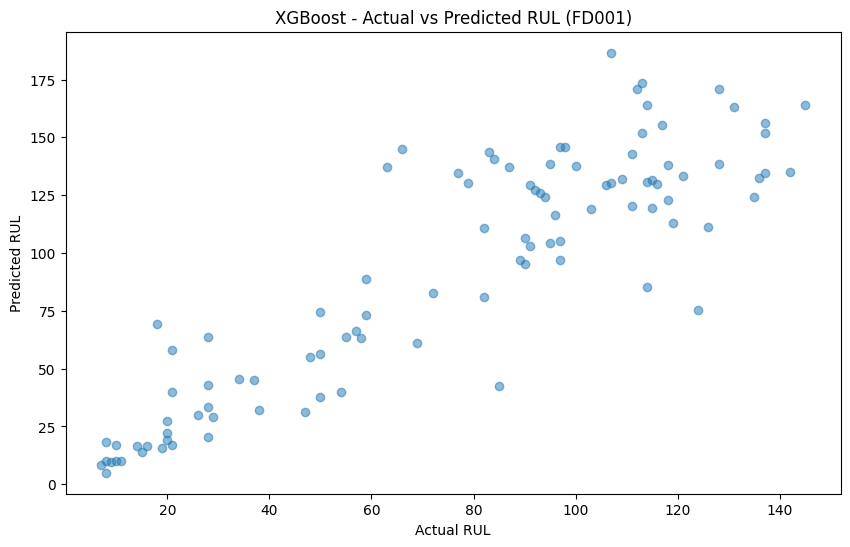

In [ ]:
# Actual vs Predicted RUL - FD001

import matplotlib.pyplot as plt

dataset_name = "FD001"

X_test = test_data[dataset_name]["X"]
y_test = test_data[dataset_name]["y"]

predicted_rul = xgb_model.predict(X_test)

plt.figure(figsize=(10, 6))

plt.scatter(
    y_test,
    predicted_rul,
    alpha=0.5
)

plt.xlabel("Actual RUL")
plt.ylabel("Predicted RUL")
plt.title("XGBoost - Actual vs Predicted RUL (FD001)")

plt.show()

In [ ]:
# Create Risk Labels from RUL

def create_risk_label(rul):

    if rul > 30:
        return "Healthy"

    elif rul > 10:
        return "Warning"

    else:
        return "High Risk"


combined_train["Risk"] = combined_train["RUL"].apply(
    create_risk_label
)

print("Risk label distribution:")
print(combined_train["Risk"].value_counts())

Risk label distribution:
Risk
Healthy      110287
Warning       11340
High Risk      6237
Name: count, dtype: int64


In [ ]:
# Prepare Classification Data

from sklearn.preprocessing import LabelEncoder

X_class_train = combined_train[common_features].copy()
y_class_train = combined_train["Risk"].copy()

# Encode risk labels into numbers
label_encoder = LabelEncoder()

y_class_train_encoded = label_encoder.fit_transform(
    y_class_train
)

print("Classes:")
for i, label in enumerate(label_encoder.classes_):
    print(i, "->", label)

print("\nX shape:", X_class_train.shape)
print("y shape:", y_class_train_encoded.shape)

Classes:
0 -> Healthy
1 -> High Risk
2 -> Warning

X shape: (127864, 129)
y shape: (127864,)


In [ ]:
class_weight="balanced"

In [ ]:
# Random Forest Classifier

from sklearn.ensemble import RandomForestClassifier

rf_classifier = RandomForestClassifier(
    n_estimators=100,
    random_state=42,
    n_jobs=-1,
    class_weight="balanced"
)

rf_classifier.fit(
    X_class_train,
    y_class_train_encoded
)

print("Random Forest Classifier training completed.")

Random Forest Classifier training completed.


In [ ]:
# Evaluate Random Forest Classifier

from sklearn.metrics import classification_report, confusion_matrix

for name in train_val_splits:

    val = train_val_splits[name]["val"].copy()

    # Features
    X_val = val[common_features]

    # True risk labels
    y_val_risk = val["RUL"].apply(
        create_risk_label
    )

    # Encode labels using the same encoder
    y_val_encoded = label_encoder.transform(
        y_val_risk
    )

    # Predictions
    y_pred = rf_classifier.predict(X_val)

    print("=" * 60)
    print(name)
    print("=" * 60)

    print(
        classification_report(
            y_val_encoded,
            y_pred,
            target_names=label_encoder.classes_,
            zero_division=0
        )
    )

    print("Confusion Matrix:")
    print(
        confusion_matrix(
            y_val_encoded,
            y_pred
        )
    )

FD001
              precision    recall  f1-score   support

     Healthy       0.96      0.99      0.98      3419
   High Risk       0.89      0.83      0.86       220
     Warning       0.79      0.61      0.69       400

    accuracy                           0.95      4039
   macro avg       0.88      0.81      0.84      4039
weighted avg       0.94      0.95      0.94      4039

Confusion Matrix:
[[3392    0   27]
 [   0  183   37]
 [ 131   23  246]]
FD002
              precision    recall  f1-score   support

     Healthy       0.94      0.99      0.97      8897
   High Risk       0.85      0.72      0.78       572
     Warning       0.70      0.45      0.55      1040

    accuracy                           0.92     10509
   macro avg       0.83      0.72      0.77     10509
weighted avg       0.91      0.92      0.92     10509

Confusion Matrix:
[[8828    3   66]
 [  28  414  130]
 [ 502   70  468]]
FD003
              precision    recall  f1-score   support

     Healthy       

In [ ]:
# XGBoost Classifier

from xgboost import XGBClassifier
from sklearn.utils.class_weight import compute_sample_weight

# Balanced sample weights
sample_weights = compute_sample_weight(
    class_weight="balanced",
    y=y_class_train_encoded
)

xgb_classifier = XGBClassifier(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=6,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    n_jobs=-1,
    eval_metric="mlogloss"
)

xgb_classifier.fit(
    X_class_train,
    y_class_train_encoded,
    sample_weight=sample_weights
)

print("XGBoost Classifier training completed.")

XGBoost Classifier training completed.


In [ ]:
# Evaluate XGBoost Classifier

xgb_class_results = []

for name in train_val_splits:

    val = train_val_splits[name]["val"].copy()

    # Features
    X_val = val[common_features]

    # True risk labels
    y_val_risk = val["RUL"].apply(
        create_risk_label
    )

    # Encode using the same label encoder
    y_val_encoded = label_encoder.transform(
        y_val_risk
    )

    # Predictions
    y_pred = xgb_classifier.predict(X_val)

    # Classification report
    report = classification_report(
        y_val_encoded,
        y_pred,
        target_names=label_encoder.classes_,
        output_dict=True,
        zero_division=0
    )

    xgb_class_results.append({
        "Dataset": name,

        "Accuracy": report["accuracy"],

        "High Risk Precision": report["High Risk"]["precision"],
        "High Risk Recall": report["High Risk"]["recall"],
        "High Risk F1": report["High Risk"]["f1-score"],

        "Warning Precision": report["Warning"]["precision"],
        "Warning Recall": report["Warning"]["recall"],
        "Warning F1": report["Warning"]["f1-score"],

        "Macro F1": report["macro avg"]["f1-score"]
    })

    print("=" * 60)
    print(name)
    print("=" * 60)

    print(
        classification_report(
            y_val_encoded,
            y_pred,
            target_names=label_encoder.classes_,
            zero_division=0
        )
    )

    print("Confusion Matrix:")
    print(
        confusion_matrix(
            y_val_encoded,
            y_pred
        )
    )

xgb_class_results_df = pd.DataFrame(
    xgb_class_results
)

print("\nXGBoost Classification Summary:")
display(xgb_class_results_df)

FD001
              precision    recall  f1-score   support

     Healthy       0.99      0.95      0.97      3419
   High Risk       0.85      0.88      0.86       220
     Warning       0.64      0.82      0.72       400

    accuracy                           0.94      4039
   macro avg       0.83      0.88      0.85      4039
weighted avg       0.95      0.94      0.94      4039

Confusion Matrix:
[[3261    0  158]
 [   0  194   26]
 [  38   35  327]]
FD002
              precision    recall  f1-score   support

     Healthy       0.99      0.93      0.96      8897
   High Risk       0.79      0.85      0.82       572
     Warning       0.55      0.80      0.65      1040

    accuracy                           0.92     10509
   macro avg       0.78      0.86      0.81     10509
weighted avg       0.94      0.92      0.92     10509

Confusion Matrix:
[[8305    3  589]
 [   0  489   83]
 [  78  130  832]]
FD003
              precision    recall  f1-score   support

     Healthy       

,Dataset,Accuracy,High Risk Precision,High Risk Recall,High Risk F1,Warning Precision,Warning Recall,Warning F1,Macro F1
0,FD001,0.936370,0.847162,0.881818,0.864143,0.639922,0.8175,0.717892,0.850953
1,FD002,0.915977,0.786174,0.854895,0.819095,0.553191,0.8000,0.654088,0.811470
2,FD003,0.967249,0.896552,0.945455,0.920354,0.740365,0.9125,0.817469,0.907690
3,FD004,0.926137,0.797364,0.880000,0.836646,0.514215,0.8320,0.635600,0.812457


In [ ]:
# Final Test Evaluation - XGBoost Classifier

xgb_test_class_results = []

for name in test_data:

    # Test features
    X_test = test_data[name]["X"]

    # True RUL
    y_test_rul = test_data[name]["y"]

    # Convert RUL to true risk labels
    y_test_risk = y_test_rul.apply(
        create_risk_label
    )

    # Encode labels
    y_test_encoded = label_encoder.transform(
        y_test_risk
    )

    # Predictions
    y_pred = xgb_classifier.predict(X_test)

    # Classification report
    report = classification_report(
        y_test_encoded,
        y_pred,
        target_names=label_encoder.classes_,
        output_dict=True,
        zero_division=0
    )

    xgb_test_class_results.append({
        "Dataset": name,
        "Accuracy": report["accuracy"],

        "High Risk Precision": report["High Risk"]["precision"],
        "High Risk Recall": report["High Risk"]["recall"],
        "High Risk F1": report["High Risk"]["f1-score"],

        "Warning Precision": report["Warning"]["precision"],
        "Warning Recall": report["Warning"]["recall"],
        "Warning F1": report["Warning"]["f1-score"],

        "Macro F1": report["macro avg"]["f1-score"]
    })

    print("=" * 60)
    print(name)
    print("=" * 60)

    print(
        classification_report(
            y_test_encoded,
            y_pred,
            target_names=label_encoder.classes_,
            zero_division=0
        )
    )

    print("Confusion Matrix:")
    print(
        confusion_matrix(
            y_test_encoded,
            y_pred
        )
    )

xgb_test_class_results_df = pd.DataFrame(
    xgb_test_class_results
)

print("\nXGBoost Final Test Classification Results:")
display(xgb_test_class_results_df)

FD001
              precision    recall  f1-score   support

     Healthy       0.97      0.96      0.97        75
   High Risk       0.71      0.71      0.71         7
     Warning       0.74      0.78      0.76        18

    accuracy                           0.91       100
   macro avg       0.81      0.82      0.81       100
weighted avg       0.91      0.91      0.91       100

Confusion Matrix:
[[72  0  3]
 [ 0  5  2]
 [ 2  2 14]]
FD002
              precision    recall  f1-score   support

     Healthy       0.99      0.86      0.92       198
   High Risk       0.56      0.82      0.67        22
     Warning       0.44      0.62      0.51        39

    accuracy                           0.82       259
   macro avg       0.66      0.77      0.70       259
weighted avg       0.87      0.82      0.84       259

Confusion Matrix:
[[171   0  27]
 [  0  18   4]
 [  1  14  24]]
FD003
              precision    recall  f1-score   support

     Healthy       0.99      0.95      0.97   

,Dataset,Accuracy,High Risk Precision,High Risk Recall,High Risk F1,Warning Precision,Warning Recall,Warning F1,Macro F1
0,FD001,0.910000,0.714286,0.714286,0.714286,0.736842,0.777778,0.756757,0.812495
1,FD002,0.822394,0.562500,0.818182,0.666667,0.436364,0.615385,0.510638,0.700543
2,FD003,0.950000,1.000000,1.000000,1.000000,0.764706,0.928571,0.838710,0.935621
3,FD004,0.899194,0.733333,0.785714,0.758621,0.629630,0.871795,0.731183,0.813892


In [ ]:
# Isolation Forest - Anomaly Detection

from sklearn.ensemble import IsolationForest

# Use the combined training features
X_anomaly_train = combined_train[common_features].copy()

isolation_forest = IsolationForest(
    n_estimators=200,
    contamination=0.01,
    random_state=42,
    n_jobs=-1
)

isolation_forest.fit(
    X_anomaly_train
)

print("Isolation Forest training completed.")

Isolation Forest training completed.


In [ ]:
# Detect Anomalies on Final Test Set

anomaly_results = []

for name in test_data:

    X_test = test_data[name]["X"]

    # Predict anomaly status
    anomaly_prediction = isolation_forest.predict(
        X_test
    )

    # Calculate anomaly score
    anomaly_scores = isolation_forest.decision_function(
        X_test
    )

    # Create result DataFrame
    results = pd.DataFrame({
        "engine_id": test_data[name]["engine_id"],
        "cycle": test_data[name]["cycle"],
        "RUL": test_data[name]["y"],
        "Anomaly": anomaly_prediction,
        "Anomaly Score": anomaly_scores
    })

    # Convert labels to readable names
    results["Status"] = results["Anomaly"].map({
        1: "Normal",
        -1: "Anomaly"
    })

    results["Risk"] = results["RUL"].apply(
        create_risk_label
    )

    anomaly_results.append({
        "Dataset": name,
        "Data": results
    })

    print("=" * 60)
    print(name)
    print("=" * 60)

    print(
        results["Status"].value_counts()
    )

    print("\nAnomaly percentage:")

    anomaly_percentage = (
        (results["Anomaly"] == -1).mean() * 100
    )

    print(
        f"{anomaly_percentage:.2f}%"
    )

FD001
Status
Normal    100
Name: count, dtype: int64

Anomaly percentage:
0.00%
FD002
Status
Normal    259
Name: count, dtype: int64

Anomaly percentage:
0.00%
FD003
Status
Normal    100
Name: count, dtype: int64

Anomaly percentage:
0.00%
FD004
Status
Normal     246
Anomaly      2
Name: count, dtype: int64

Anomaly percentage:
0.81%


In [ ]:
# Analyze Anomalies vs Risk

for item in anomaly_results:

    name = item["Dataset"]
    results = item["Data"]

    print("=" * 60)
    print(name)
    print("=" * 60)

    # Cross-tabulation
    comparison = pd.crosstab(
        results["Risk"],
        results["Status"],
        margins=True
    )

    print("\nRisk vs Anomaly Status:")
    display(comparison)

    # Show detected anomalies
    anomalies = results[
        results["Status"] == "Anomaly"
    ].copy()

    print("\nDetected Anomalies:")

    if len(anomalies) > 0:

        display(
            anomalies[
                [
                    "engine_id",
                    "cycle",
                    "RUL",
                    "Risk",
                    "Anomaly Score"
                ]
            ].sort_values("Anomaly Score")
        )

    else:
        print("No anomalies detected.")

FD001

Risk vs Anomaly Status:


Status,Normal,All
Risk,,
Healthy,75,75
High Risk,7,7
Warning,18,18
All,100,100



Detected Anomalies:
No anomalies detected.
FD002

Risk vs Anomaly Status:


Status,Normal,All
Risk,,
Healthy,198,198
High Risk,22,22
Warning,39,39
All,259,259



Detected Anomalies:
No anomalies detected.
FD003

Risk vs Anomaly Status:


Status,Normal,All
Risk,,
Healthy,80,80
High Risk,6,6
Warning,14,14
All,100,100



Detected Anomalies:
No anomalies detected.
FD004

Risk vs Anomaly Status:


Status,Anomaly,Normal,All
Risk,,,
Healthy,1,194,195
High Risk,0,14,14
Warning,1,38,39
All,2,246,248



Detected Anomalies:


,engine_id,cycle,RUL,Risk,Anomaly Score
132,FD004_133,74,126,Healthy,-0.007586
212,FD004_213,288,14,Warning,-0.002154


In [ ]:
# Analyze Anomaly Scores

for item in anomaly_results:

    name = item["Dataset"]
    results = item["Data"].copy()

    print("=" * 60)
    print(name)
    print("=" * 60)

    print("\nAnomaly Score Statistics:")
    print(
        results["Anomaly Score"].describe()
    )

    print("\nLowest anomaly scores:")

    display(
        results[
            [
                "engine_id",
                "cycle",
                "RUL",
                "Risk",
                "Anomaly Score"
            ]
        ]
        .sort_values("Anomaly Score")
        .head(10)
    )

FD001

Anomaly Score Statistics:
count    100.000000
mean       0.157748
std        0.016128
min        0.115971
25%        0.148792
50%        0.162961
75%        0.170101
max        0.180702
Name: Anomaly Score, dtype: float64

Lowest anomaly scores:


,engine_id,cycle,RUL,Risk,Anomaly Score
34,FD001_35,198,11,Warning,0.115971
33,FD001_34,203,7,High Risk,0.117373
55,FD001_56,136,15,Warning,0.120362
41,FD001_42,156,10,High Risk,0.123055
99,FD001_100,198,20,Warning,0.123533
23,FD001_24,186,20,Warning,0.126714
75,FD001_76,205,10,High Risk,0.128492
80,FD001_81,213,8,High Risk,0.128938
81,FD001_82,162,9,High Risk,0.129041
19,FD001_20,184,16,Warning,0.129507


FD002

Anomaly Score Statistics:
count    259.000000
mean       0.101411
std        0.032940
min        0.001622
25%        0.079449
50%        0.103901
75%        0.126437
max        0.168148
Name: Anomaly Score, dtype: float64

Lowest anomaly scores:


,engine_id,cycle,RUL,Risk,Anomaly Score
92,FD002_93,76,183,Healthy,0.001622
189,FD002_190,158,12,Warning,0.006890
252,FD002_253,139,43,Healthy,0.018378
157,FD002_158,171,15,Warning,0.024764
233,FD002_234,147,89,Healthy,0.025526
129,FD002_130,141,121,Healthy,0.027966
68,FD002_69,158,115,Healthy,0.030079
205,FD002_206,162,48,Healthy,0.034900
62,FD002_63,174,39,Healthy,0.036145
202,FD002_203,115,192,Healthy,0.038543


FD003

Anomaly Score Statistics:
count    100.000000
mean       0.136990
std        0.038489
min        0.032447
25%        0.132734
50%        0.153202
75%        0.161801
max        0.178099
Name: Anomaly Score, dtype: float64

Lowest anomaly scores:


,engine_id,cycle,RUL,Risk,Anomaly Score
81,FD003_82,194,6,High Risk,0.032447
23,FD003_24,475,9,High Risk,0.042452
45,FD003_46,180,7,High Risk,0.046218
91,FD003_92,266,14,Warning,0.048081
38,FD003_39,310,8,High Risk,0.048728
98,FD003_99,289,8,High Risk,0.048772
93,FD003_94,333,10,High Risk,0.050378
20,FD003_21,263,18,Warning,0.050829
80,FD003_81,155,15,Warning,0.059753
77,FD003_78,279,20,Warning,0.062428


FD004

Anomaly Score Statistics:
count    248.000000
mean       0.102375
std        0.036968
min       -0.007586
25%        0.073718
50%        0.105808
75%        0.131845
max        0.169096
Name: Anomaly Score, dtype: float64

Lowest anomaly scores:


,engine_id,cycle,RUL,Risk,Anomaly Score
132,FD004_133,74,126,Healthy,-0.007586
212,FD004_213,288,14,Warning,-0.002154
121,FD004_122,117,192,Healthy,0.013480
241,FD004_242,112,81,Healthy,0.016116
139,FD004_140,160,146,Healthy,0.022513
32,FD004_33,107,147,Healthy,0.023791
72,FD004_73,149,23,Warning,0.027901
225,FD004_226,59,88,Healthy,0.028725
126,FD004_127,98,195,Healthy,0.029577
171,FD004_172,132,12,Warning,0.033443


In [ ]:
# Final Machine Health Monitoring Results

monitoring_results = {}

for item in anomaly_results:

    name = item["Dataset"]
    anomaly_df = item["Data"].copy()

    # Test features
    X_test = test_data[name]["X"]

    # 1. Predict RUL
    predicted_rul = xgb_model.predict(
        X_test
    )

    # Prevent negative RUL predictions
    predicted_rul = np.maximum(
        predicted_rul,
        0
    )

    # 2. Predict Risk
    predicted_risk_encoded = xgb_classifier.predict(
        X_test
    )

    predicted_risk = label_encoder.inverse_transform(
        predicted_risk_encoded
    )

    # 3. Create final monitoring table
    monitoring_df = pd.DataFrame({
        "engine_id": test_data[name]["engine_id"],
        "cycle": test_data[name]["cycle"],
        "Actual RUL": test_data[name]["y"],
        "Predicted RUL": predicted_rul,
        "Predicted Risk": predicted_risk,
        "Anomaly Score": anomaly_df["Anomaly Score"],
        "Anomaly Status": anomaly_df["Status"]
    })

    monitoring_results[name] = monitoring_df

    print("=" * 60)
    print(name)
    print("=" * 60)

    display(
        monitoring_df.head(10)
    )

FD001


,engine_id,cycle,Actual RUL,Predicted RUL,Predicted Risk,Anomaly Score,Anomaly Status
0,FD001_1,31,112,170.788406,Healthy,0.167645,Normal
1,FD001_2,49,98,145.723190,Healthy,0.167154,Normal
2,FD001_3,126,69,61.254913,Healthy,0.147840,Normal
3,FD001_4,106,82,110.915077,Healthy,0.157625,Normal
4,FD001_5,98,91,129.299362,Healthy,0.162823,Normal
5,FD001_6,105,93,126.138580,Healthy,0.164085,Normal
6,FD001_7,160,91,103.006210,Healthy,0.171048,Normal
7,FD001_8,166,95,138.393097,Healthy,0.159907,Normal
8,FD001_9,55,111,120.156219,Healthy,0.168933,Normal
9,FD001_10,192,96,116.245979,Healthy,0.174555,Normal


FD002


,engine_id,cycle,Actual RUL,Predicted RUL,Predicted Risk,Anomaly Score,Anomaly Status
0,FD002_1,258,18,0.000000,Warning,0.116299,Normal
1,FD002_2,55,79,109.987877,Healthy,0.061402,Normal
2,FD002_3,165,106,131.417465,Healthy,0.083633,Normal
3,FD002_4,86,110,110.205116,Healthy,0.121841,Normal
4,FD002_5,148,15,13.518848,High Risk,0.101773,Normal
5,FD002_6,63,155,175.657288,Healthy,0.127426,Normal
6,FD002_7,184,6,30.444338,Warning,0.145535,Normal
7,FD002_8,173,90,63.673538,Healthy,0.087657,Normal
8,FD002_9,161,11,5.158071,High Risk,0.090504,Normal
9,FD002_10,84,79,97.180695,Healthy,0.102966,Normal


FD003


,engine_id,cycle,Actual RUL,Predicted RUL,Predicted Risk,Anomaly Score,Anomaly Status
0,FD003_1,233,44,45.169048,Healthy,0.090445,Normal
1,FD003_2,124,51,99.731491,Healthy,0.157865,Normal
2,FD003_3,234,27,31.100674,Warning,0.078321,Normal
3,FD003_4,68,120,161.261261,Healthy,0.174517,Normal
4,FD003_5,138,101,196.948456,Healthy,0.151514,Normal
5,FD003_6,64,99,132.811935,Healthy,0.168332,Normal
6,FD003_7,158,71,70.393196,Healthy,0.152093,Normal
7,FD003_8,192,55,66.433067,Healthy,0.153083,Normal
8,FD003_9,238,55,119.471565,Healthy,0.171144,Normal
9,FD003_10,131,66,118.247055,Healthy,0.169014,Normal


FD004


,engine_id,cycle,Actual RUL,Predicted RUL,Predicted Risk,Anomaly Score,Anomaly Status
0,FD004_1,230,22,70.297325,Warning,0.074966,Normal
1,FD004_2,153,39,77.411690,Healthy,0.069351,Normal
2,FD004_3,141,107,79.006340,Healthy,0.154546,Normal
3,FD004_4,208,75,148.732224,Healthy,0.085985,Normal
4,FD004_5,51,149,90.699890,Healthy,0.117049,Normal
5,FD004_6,146,78,173.494980,Healthy,0.128203,Normal
6,FD004_7,54,94,114.972298,Healthy,0.120334,Normal
7,FD004_8,248,14,12.789061,Warning,0.156186,Normal
8,FD004_9,284,99,122.870186,Healthy,0.113081,Normal
9,FD004_10,23,162,170.267090,Healthy,0.099874,Normal


In [ ]:
# RUL Prediction Analysis

rul_analysis = []

for name in test_data:

    actual_rul = test_data[name]["y"].values
    predicted_rul = xgb_model.predict(
        test_data[name]["X"]
    )

    predicted_rul = np.maximum(
        predicted_rul,
        0
    )

    mae = mean_absolute_error(
        actual_rul,
        predicted_rul
    )

    rmse = np.sqrt(
        mean_squared_error(
            actual_rul,
            predicted_rul
        )
    )

    rul_analysis.append({
        "Dataset": name,
        "MAE": mae,
        "RMSE": rmse,
        "Mean Actual RUL": actual_rul.mean(),
        "Mean Predicted RUL": predicted_rul.mean()
    })

rul_analysis_df = pd.DataFrame(
    rul_analysis
)

print("Final RUL Analysis:")
display(rul_analysis_df)

Final RUL Analysis:


,Dataset,MAE,RMSE,Mean Actual RUL,Mean Predicted RUL
0,FD001,21.101923,28.884634,75.520000,91.775696
1,FD002,22.995291,30.378644,81.185328,89.049301
2,FD003,32.946079,46.060921,75.320000,104.712708
3,FD004,28.553524,37.331143,86.552419,102.632149


In [ ]:
# Save Trained Models

import joblib

joblib.dump(xgb_model, "xgb_rul_model.pkl")
joblib.dump(xgb_classifier, "xgb_risk_classifier.pkl")
joblib.dump(isolation_forest, "isolation_forest.pkl")
joblib.dump(label_encoder, "label_encoder.pkl")

print("Models saved successfully.")

Models saved successfully.


In [ ]:
# Save Feature Configuration

joblib.dump(common_features, "feature_columns.pkl")

print("Number of saved features:", len(common_features))

Number of saved features: 129


In [ ]:
# Check Saved Model Files

import os

model_files = [
    "xgb_rul_model.pkl",
    "xgb_risk_classifier.pkl",
    "isolation_forest.pkl",
    "label_encoder.pkl",
    "feature_columns.pkl"
]

for file in model_files:

    if os.path.exists(file):
        print("✓", file)
    else:
        print("✗", file)

✓ xgb_rul_model.pkl
✓ xgb_risk_classifier.pkl
✓ isolation_forest.pkl
✓ label_encoder.pkl
✓ feature_columns.pkl


## Deployment (Streamlit)

This writes the tested `app.py` used on the live deployment:
https://predictive-maintenance-system-ljioah2est9k9ydkpufqhq.streamlit.app/


In [ ]:
%%writefile app.py
import re

import numpy as np
import pandas as pd
import streamlit as st
import joblib

# ============================================
# Page Configuration
# ============================================

st.set_page_config(
    page_title="Machine Health Monitoring",
    page_icon="⚙️",
    layout="wide"
)

# ============================================
# Load Models (cached so they load once, not on every click)
# ============================================

@st.cache_resource
def load_models():
    return {
        "rul_model": joblib.load("xgb_rul_model.pkl"),
        "risk_classifier": joblib.load("xgb_risk_classifier.pkl"),
        "isolation_forest": joblib.load("isolation_forest.pkl"),
        "label_encoder": joblib.load("label_encoder.pkl"),
        "feature_columns": joblib.load("feature_columns.pkl"),
    }

models = load_models()
xgb_rul_model = models["rul_model"]
xgb_risk_classifier = models["risk_classifier"]
isolation_forest = models["isolation_forest"]
label_encoder = models["label_encoder"]
feature_columns = models["feature_columns"]

ROLLING_WINDOWS = [5, 20]  # must match training (see notebook cell 13)


def natural_sort_key(name: str):
    """Sort sensor1, sensor2, ..., sensor21 in numeric order, not alphabetical."""
    match = re.search(r"(\d+)", name)
    return int(match.group(1)) if match else 0


# Raw sensor names only (no engineered suffix), sorted numerically
sensor_columns = sorted(
    (
        col for col in feature_columns
        if col.startswith("sensor")
        and "_rolling_" not in col
        and "_rate_of_change" not in col
    ),
    key=natural_sort_key,
)

# ============================================
# Title
# ============================================

st.title("⚙️ Machine Health Monitoring System")
st.write("Predictive Maintenance Dashboard using XGBoost and Isolation Forest")
st.caption(
    "Trained on the NASA C-MAPSS turbofan engine degradation dataset — "
    "built for this specific set of 21 engine sensors, not general-purpose machinery."
)

# ============================================
# Feature engineering — mirrors training exactly (notebook cell 13)
# ============================================

def engineer_features(history_df: pd.DataFrame) -> pd.Series:
    """
    Takes a sensor-reading history for ONE engine (sorted by cycle) and
    returns the fully engineered feature row (raw + rolling + rate-of-change)
    for the LAST cycle, in the exact column order the models expect.
    """
    df = history_df.sort_values("cycle").copy()

    for sensor in sensor_columns:
        for w in ROLLING_WINDOWS:
            df[f"{sensor}_rolling_mean_{w}"] = (
                df[sensor].rolling(window=w, min_periods=1).mean()
            )
            df[f"{sensor}_rolling_std_{w}"] = (
                df[sensor].rolling(window=w, min_periods=1).std()
            )
        df[f"{sensor}_rate_of_change"] = df[sensor].diff()

    last_row = df.iloc[[-1]].copy()

    for feature in feature_columns:
        if feature not in last_row.columns:
            last_row[feature] = 0.0

    # First-cycle std/diff can be NaN (nothing to compare against yet)
    last_row[feature_columns] = last_row[feature_columns].fillna(0.0)

    return last_row[feature_columns]


def run_prediction(input_row: pd.DataFrame):
    predicted_rul = max(float(xgb_rul_model.predict(input_row)[0]), 0)

    predicted_risk_encoded = xgb_risk_classifier.predict(input_row)[0]
    predicted_risk = label_encoder.inverse_transform([predicted_risk_encoded])[0]

    anomaly_prediction = isolation_forest.predict(input_row)[0]
    anomaly_score = isolation_forest.decision_function(input_row)[0]
    anomaly_status = "Anomaly" if anomaly_prediction == -1 else "Normal"

    return predicted_rul, predicted_risk, anomaly_status, anomaly_score


def show_results(dataset, engine_id, cycle, predicted_rul, predicted_risk, anomaly_status, anomaly_score):
    st.subheader("Machine Health Results")

    col1, col2, col3, col4 = st.columns(4)
    col1.metric("Predicted RUL", f"{predicted_rul:.1f} cycles")
    col2.metric("Risk", predicted_risk)
    col3.metric("Anomaly Status", anomaly_status)
    col4.metric("Anomaly Score", f"{anomaly_score:.4f}")

    if predicted_risk == "High Risk" or anomaly_status == "Anomaly":
        st.error("⚠️ This engine needs attention.")
    elif predicted_risk == "Warning":
        st.warning("This engine should be monitored closely.")
    else:
        st.success("Engine health looks normal.")

    st.subheader("Machine Summary")
    summary = pd.DataFrame({
        "Parameter": ["Dataset", "Engine ID", "Current Cycle", "Predicted RUL", "Predicted Risk", "Anomaly Status"],
        "Value": [dataset, engine_id, cycle, f"{predicted_rul:.2f} cycles", predicted_risk, anomaly_status],
    })
    st.table(summary)


# ============================================
# Sidebar
# ============================================

st.sidebar.header("Engine Information")
dataset = st.sidebar.selectbox("Dataset", ["FD001", "FD002", "FD003", "FD004"])

# ============================================
# Input mode: CSV upload (recommended) or manual entry
# ============================================

tab_csv, tab_manual = st.tabs(["📄 Upload CSV (recommended)", "⌨️ Manual entry"])

# ---------- CSV tab ----------
with tab_csv:
    st.write(
        "Upload a CSV with this engine's sensor readings over time — one row "
        "per cycle. More history gives more accurate rolling/trend features "
        "(the models were trained on 5- and 20-cycle rolling windows)."
    )

    template = pd.DataFrame({"engine_id": [f"{dataset}_1"] * 3, "cycle": [1, 2, 3]})
    for s in sensor_columns:
        template[s] = 0.0
    st.download_button(
        "⬇️ Download CSV template",
        template.to_csv(index=False),
        file_name="sensor_readings_template.csv",
        mime="text/csv",
    )
    st.caption("Including an `engine_id` column is optional — if present, it's read automatically instead of typing it.")

    uploaded_file = st.file_uploader("Sensor readings CSV", type=["csv"])

    if uploaded_file is not None:
        try:
            data = pd.read_csv(uploaded_file)
        except Exception as e:
            st.error(f"Couldn't read that CSV: {e}")
            data = None

        if data is not None:
            missing = [c for c in ["cycle", *sensor_columns] if c not in data.columns]
            if missing:
                st.error(
                    "The CSV is missing these expected column(s): "
                    + ", ".join(missing)
                    + ". Use the template above to check the exact column names."
                )
            else:
                st.success(f"Loaded {len(data)} cycle(s).")

                if "engine_id" in data.columns:
                    detected_ids = data["engine_id"].dropna().unique()
                    if len(detected_ids) > 1:
                        st.warning(
                            f"This CSV has {len(detected_ids)} different engine_id values "
                            f"({', '.join(map(str, detected_ids))}). Using the last row's "
                            "engine, since the models look at the most recent cycle."
                        )
                    engine_id = str(data["engine_id"].iloc[-1])
                    st.info(f"Engine ID (from CSV): **{engine_id}**")
                else:
                    engine_id = st.text_input(
                        "Engine ID (not found in CSV — enter manually)",
                        value=f"{dataset}_1",
                        key="csv_engine_id_fallback",
                    )

                st.dataframe(data.tail(10), use_container_width=True)

                last_cycle = int(data["cycle"].max())

                if st.button("🔍 Analyze Machine Health", type="primary", key="csv_analyze"):
                    engine_data = data
                    if "engine_id" in data.columns and len(data["engine_id"].dropna().unique()) > 1:
                        engine_data = data[data["engine_id"] == engine_id]

                    input_row = engineer_features(engine_data)
                    predicted_rul, predicted_risk, anomaly_status, anomaly_score = run_prediction(input_row)
                    show_results(
                        dataset, engine_id, last_cycle,
                        predicted_rul, predicted_risk, anomaly_status, anomaly_score,
                    )


In [ ]:
import os

required_files = [
    "app.py",
    "xgb_rul_model.pkl",
    "xgb_risk_classifier.pkl",
    "isolation_forest.pkl",
    "label_encoder.pkl",
    "feature_columns.pkl",
]

for f in required_files:
    print(f, "->", "OK" if os.path.exists(f) else "MISSING")


The app is deployed on **Streamlit Community Cloud** (not run from Colab — Colab sessions are temporary). To update the live app: edit `app.py` in the GitHub repo and commit — Streamlit redeploys automatically within ~a minute.


In [ ]:
!ls -lh /content

total 13M
-rw-r--r-- 1 root root  13M Sep 13 07:28 archive.zip
drwxr-xr-x 1 root root 4.0K Sep  4 13:25 sample_data


In [ ]:
import zipfile

zip_path = "/content/archive.zip"
extract_path = "/content/CMAPSSData"

with zipfile.ZipFile(zip_path, "r") as zip_ref:
    zip_ref.extractall(extract_path)

print("Decompression successful!")
print(os.listdir(extract_path))

In [ ]:
import os

print(os.listdir("/content/CMAPSSData/CMaps"))

['train_FD003.txt', 'test_FD002.txt', 'RUL_FD004.txt', 'train_FD004.txt', 'train_FD001.txt', 'RUL_FD003.txt', 'RUL_FD002.txt', 'RUL_FD001.txt', 'test_FD001.txt', 'test_FD003.txt', 'test_FD004.txt', 'train_FD002.txt', 'readme.txt', 'Damage Propagation Modeling.pdf', 'x.txt']


In [ ]:
from google.colab import files

for f in [
    "app.py",
    "xgb_rul_model.pkl",
    "xgb_risk_classifier.pkl",
    "isolation_forest.pkl",
    "label_encoder.pkl",
    "feature_columns.pkl"
]:
    files.download(f)
